# Sky Wong
## Cross-Sectional Equity Risk Premium Engine
### Machine-learning forecasts of stock returns -> backtested long/short portfolio
1. Project Overview
This engine forecasts next-month excess returns for a universe of U.S. equities using a
standard set of cross-sectional stock characteristics (momentum, liquidity, volatility,
size, valuation) and compares linear, penalized-linear, tree-based, and neural-network
models on out-of-sample predictive accuracy. Forecasts are converted into a monthly
decile-sorted long/short portfolio, and performance is measured with the metrics an
allocator actually cares about: out-of-sample R², Sharpe ratio, drawdown, turnover, and
alpha relative to a market benchmark.
The design follows the methodology used in the empirical asset-pricing / return-prediction
literature: build a broad panel of firm-level characteristics, fit a model on a rolling
training window, validate hyperparameters on a held-out window, and evaluate strictly
out-of-sample. Everything here is implemented independently against free, publicly
available market data (Yahoo Finance via `yfinance`) rather than a licensed CRSP feed, so
the pipeline is fully reproducible without a data subscription.
2. Real-World Finance Use Case
Quant equity research: screening which firm characteristics carry incremental
predictive power for returns, and whether nonlinear interactions among them matter.
Systematic long/short strategy construction: converting a return forecast into
a rules-based, value-weighted decile spread portfolio with realistic turnover and
drawdown reporting.
Model risk / model selection: a reusable harness for comparing linear vs.
regularized vs. ensemble vs. neural-network forecasters under an identical training,
validation, and testing protocol — the same question a quant PM or model-validation
team asks before allocating capital to a signal.
Factor timing: the aggregate-market module reuses the same pipeline to time an
index (e.g., SPY) rather than a cross-section of single names.

In [7]:
!pip install -q yfinance pandas_datareader plotly statsmodels scikit-learn pyarrow

import warnings
warnings.filterwarnings("ignore")
import logging
import pandas as pd
import numpy as np
import yfinance as yf

print("Environment ready.")


Environment ready.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Configuration

All tunable parameters (universe, dates, hyperparameters) live in one place so the
rest of the notebook never hardcodes a magic number.

In [8]:
UNIVERSE = [
    "AAPL","MSFT","GOOGL","AMZN","META","NVDA","TSLA","JPM","BAC","WFC","GS","V","MA",
    "JNJ","PFE","UNH","MRK","ABBV","XOM","CVX","COP","PG","KO","PEP","WMT","COST",
    "HD","MCD","NKE","DIS","NFLX","CMCSA","T","VZ","BA","CAT","GE","HON","UPS","LIN","NEE",
]
BENCHMARK_TICKER = "SPY"
START_DATE = "2012-01-01"
END_DATE = "2022-12-31"

TRAIN_YEARS = 5
VALIDATION_YEARS = 2

WINSORIZE_PCT = 0.01
MIN_HISTORY_MONTHS = 24
MOMENTUM_WINDOWS = (1, 6, 12)

N_DECILES = 10
RISK_FREE_ANNUAL = 0.02
RANDOM_STATE = 42

print(f"Universe size: {len(UNIVERSE)} tickers + benchmark {BENCHMARK_TICKER}")


Universe size: 41 tickers + benchmark SPY


## 2. Data Collection Pipeline

Downloads adjusted daily OHLCV data via `yfinance`. If a live connection is not
available (e.g. a sandboxed CI environment), a seeded synthetic price generator
is used instead so the rest of the notebook can still be exercised end to end --
this fallback is logged loudly and should never be mistaken for real market data.

In [9]:
def download_prices(tickers, start, end):
    import yfinance as yf
    raw = yf.download(tickers=tickers, start=start, end=end, auto_adjust=True,
                       group_by="ticker", threads=True, progress=False)
    if raw.empty:
        raise RuntimeError("empty download")
    frames = []
    for t in tickers:
        try:
            sub = raw[t][["Close", "Volume"]].copy()
        except (KeyError, TypeError):
            sub = raw[["Close", "Volume"]].copy()
        sub.columns = ["close", "volume"]
        sub["ticker"] = t
        sub = sub.reset_index().rename(columns={"Date": "date"})
        frames.append(sub)
    return pd.concat(frames, ignore_index=True).dropna(subset=["close"])


def synthetic_prices(tickers, start, end, seed=42):
    logging.warning("Using SYNTHETIC price data -- no live market data connection available.")
    rng_dates = pd.bdate_range(start=start, end=end)
    frames = []
    for i, t in enumerate(tickers):
        rng = np.random.default_rng(seed + i)
        mu = rng.uniform(0.04, 0.14) / 252
        sigma = rng.uniform(0.15, 0.45) / np.sqrt(252)
        shocks = rng.normal(mu, sigma, size=len(rng_dates))
        regime = np.sin(np.linspace(0, rng.uniform(2, 6), len(rng_dates))) * 0.0005
        price = 20 * np.exp(np.cumsum(shocks + regime))
        base_vol = rng.uniform(5e6, 5e8)
        volume = np.abs(rng.normal(base_vol, base_vol * 0.3, size=len(rng_dates))) / price
        frames.append(pd.DataFrame({"date": rng_dates, "ticker": t, "close": price, "volume": volume}))
    return pd.concat(frames, ignore_index=True)


all_tickers = UNIVERSE + [BENCHMARK_TICKER]
try:
    prices = download_prices(all_tickers, START_DATE, END_DATE)
except Exception as e:
    logging.error(f"Live download failed: {e}")
    prices = synthetic_prices(all_tickers, START_DATE, END_DATE, seed=RANDOM_STATE)

prices["date"] = pd.to_datetime(prices["date"])
prices = prices.sort_values(["ticker", "date"]).reset_index(drop=True)
print(f"Price panel: {len(prices):,} rows across {prices['ticker'].nunique()} tickers")
prices.head()


Price panel: 115,911 rows across 42 tickers


,date,close,volume,ticker
0,2012-01-03,12.310345,302220800.0,AAPL
1,2012-01-04,12.376503,260022000.0,AAPL
2,2012-01-05,12.513906,271269600.0,AAPL
3,2012-01-06,12.644726,318292800.0,AAPL
4,2012-01-09,12.624665,394024400.0,AAPL


## 3. Data Cleaning & Feature Engineering

Builds a monthly stock-characteristic panel: momentum (1M/6M/12M), volatility,
liquidity (dollar volume, Amihud illiquidity), size, and a valuation-gap proxy.
Every characteristic is winsorized then cross-sectionally rank-normalized to
[-1, 1] within each month, and the target is next month's realized return.

In [10]:
stock_daily = prices[prices["ticker"] != BENCHMARK_TICKER].copy()
bench_daily = prices[prices["ticker"] == BENCHMARK_TICKER].copy()

stock_daily["month"] = stock_daily["date"].dt.to_period("M")
history = stock_daily.groupby("ticker")["month"].nunique()
valid = history[history >= MIN_HISTORY_MONTHS].index
stock_daily = stock_daily[stock_daily["ticker"].isin(valid)]

monthly_close = (
    stock_daily.sort_values("date").groupby(["ticker", "month"])
    .agg(close=("close", "last"), volume=("volume", "mean"), date=("date", "last"))
    .reset_index()
)

daily = stock_daily.copy()
daily["ret"] = daily.groupby("ticker")["close"].pct_change()
daily["dollar_vol"] = daily["close"] * daily["volume"]
daily["illiq_daily"] = (daily["ret"].abs() / daily["dollar_vol"].replace(0, np.nan)) * 1e6

liquidity = (
    daily.groupby(["ticker", "month"])
    .agg(avg_dollar_vol=("dollar_vol", "mean"),
         amihud_illiq=("illiq_daily", "mean"),
         vol_realized=("ret", "std"),
         vol_downside=("ret", lambda s: s[s < 0].std()))
    .reset_index()
)

panel = monthly_close.merge(liquidity, on=["ticker", "month"], how="left").sort_values(["ticker", "month"])

g = panel.groupby("ticker")["close"]
for w in MOMENTUM_WINDOWS:
    panel[f"mom_{w}m"] = g.pct_change(periods=w)
panel["mom_chg"] = panel["mom_1m"] - panel.groupby("ticker")["mom_1m"].shift(MOMENTUM_WINDOWS[-1])

panel["size_log_mktcap_proxy"] = np.log(panel["close"] * panel["avg_dollar_vol"].clip(lower=1))
trailing_avg = panel.groupby("ticker")["close"].transform(lambda s: s.rolling(24, min_periods=12).mean())
panel["valuation_gap"] = (panel["close"] - trailing_avg) / trailing_avg
panel["dollar_volume"] = np.log(panel["avg_dollar_vol"].clip(lower=1))
panel["amihud_illiq"] = np.log1p(panel["amihud_illiq"].clip(lower=0))
panel["fwd_ret"] = panel.groupby("ticker")["close"].shift(-1) / panel["close"] - 1

FEATURE_COLS = ["mom_1m","mom_6m","mom_12m","mom_chg","vol_realized","vol_downside",
                 "size_log_mktcap_proxy","dollar_volume","amihud_illiq","valuation_gap"]

clean = panel.dropna(subset=FEATURE_COLS + ["fwd_ret"]).copy()

def winsorize(s, pct):
    lo, hi = s.quantile(pct), s.quantile(1 - pct)
    return s.clip(lower=lo, upper=hi)

def rank_normalize(s):
    ranks = s.rank(method="average")
    n = ranks.notna().sum()
    return 2 * (ranks - 1) / (n - 1) - 1 if n > 1 else ranks * 0

for col in FEATURE_COLS:
    clean[col] = clean.groupby("month")[col].transform(lambda s: winsorize(s, WINSORIZE_PCT))
    clean[col] = clean.groupby("month")[col].transform(rank_normalize)

feature_panel = clean.dropna(subset=FEATURE_COLS).reset_index(drop=True)
print(f"Feature panel: {len(feature_panel):,} stock-month observations, {len(FEATURE_COLS)} features")
feature_panel[["ticker","month"] + FEATURE_COLS + ["fwd_ret"]].head()


Feature panel: 4,822 stock-month observations, 10 features


,ticker,month,mom_1m,mom_6m,mom_12m,mom_chg,vol_realized,vol_downside,size_log_mktcap_proxy,dollar_volume,amihud_illiq,valuation_gap,fwd_ret
0,AAPL,2013-02,-0.842105,-1.0,-1.0,-0.947368,0.736842,0.684211,1.000000,1.0,-1.0,-1.0,0.002854
1,AAPL,2013-03,-0.684211,-1.0,-1.0,-0.842105,0.842105,0.842105,1.000000,1.0,-1.0,-1.0,0.000271
2,AAPL,2013-04,-0.526316,-1.0,-1.0,-0.263158,0.842105,0.789474,1.000000,1.0,-1.0,-1.0,0.022419
3,AAPL,2013-05,0.000000,-1.0,-1.0,-0.263158,0.631579,0.842105,1.000000,1.0,-1.0,-1.0,-0.118293
4,AAPL,2013-06,-1.000000,-1.0,-1.0,-0.846154,-0.897436,-0.333333,0.897436,1.0,-1.0,-1.0,0.141225


## 4. Train / Validate / Test Split

A single expanding-window, strictly time-ordered split. The model never sees
test-period data during fitting or hyperparameter selection.

In [11]:
months = sorted(feature_panel["month"].unique())
train_months = months[: TRAIN_YEARS * 12]
val_months = months[TRAIN_YEARS * 12: (TRAIN_YEARS + VALIDATION_YEARS) * 12]
test_months = months[(TRAIN_YEARS + VALIDATION_YEARS) * 12:]

train_idx = feature_panel["month"].isin(train_months)
val_idx = feature_panel["month"].isin(val_months)
test_idx = feature_panel["month"].isin(test_months)

print(f"Train: {train_months[0]} -> {train_months[-1]}  ({train_idx.sum()} obs)")
print(f"Val:   {val_months[0]} -> {val_months[-1]}  ({val_idx.sum()} obs)")
print(f"Test:  {test_months[0]} -> {test_months[-1]}  ({test_idx.sum()} obs)")


Train: 2013-02 -> 2018-01  (2444 obs)
Val:   2018-02 -> 2020-01  (984 obs)
Test:  2020-02 -> 2022-11  (1394 obs)


## 5. Model Zoo -- Training & Out-of-Sample Evaluation

OLS, ElasticNet (CV-tuned), Random Forest, Gradient Boosted Trees, and an MLP
neural network, all fit on the training+validation window, all scored strictly
on the untouched test window using a zero-benchmarked out-of-sample R-squared.

In [12]:
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

X_train = feature_panel.loc[train_idx | val_idx, FEATURE_COLS]
y_train = feature_panel.loc[train_idx | val_idx, "fwd_ret"]
X_test = feature_panel.loc[test_idx, FEATURE_COLS]
y_test = feature_panel.loc[test_idx, "fwd_ret"]

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

zoo = {
    "OLS": LinearRegression(),
    "ElasticNet": ElasticNetCV(alphas=[1e-4,1e-3,1e-2,5e-2,1e-1,5e-1],
                                l1_ratio=[0.1,0.3,0.5,0.7,0.9], cv=3, max_iter=5000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=20,
                                           n_jobs=-1, random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.03,
                                                    subsample=0.8, random_state=RANDOM_STATE),
    "NeuralNet": MLPRegressor(hidden_layer_sizes=(32,16), activation="relu", solver="adam",
                               alpha=1e-3, early_stopping=True, validation_fraction=0.15,
                               max_iter=500, random_state=RANDOM_STATE),
}

def oos_r2(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return 1 - np.sum((y_true - y_pred) ** 2) / np.sum(y_true ** 2)

results = {}
for name, model in zoo.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    r2 = oos_r2(y_test.values, preds)
    pred_df = feature_panel.loc[test_idx, ["ticker","month","date","fwd_ret","size_log_mktcap_proxy"]].copy()
    pred_df["prediction"] = preds
    results[name] = {"model": model, "r2": r2, "predictions": pred_df}
    print(f"{name:<18} out-of-sample R^2 = {r2*100:6.3f}%")


OLS                out-of-sample R^2 =  2.457%
ElasticNet         out-of-sample R^2 =  2.205%
RandomForest       out-of-sample R^2 =  1.819%
GradientBoosting   out-of-sample R^2 = -0.247%
NeuralNet          out-of-sample R^2 = -4.219%


## 6. Portfolio Backtest -- Decile-Sorted Long/Short Strategy

Each month, stocks are sorted into deciles by predicted return; the strategy
goes long the top decile and short the bottom decile, value-weighted by the
size proxy.

In [13]:
def decile_sort(df, n=N_DECILES):
    df = df.copy()
    df["decile"] = df.groupby("month")["prediction"].transform(
        lambda s: pd.qcut(s.rank(method="first"), n, labels=False, duplicates="drop") + 1)
    return df

def value_weighted_decile_returns(df, weight_col="size_log_mktcap_proxy"):
    def wavg(g):
        w = g[weight_col].clip(lower=1e-6)
        return np.average(g["fwd_ret"], weights=w)
    return df.groupby(["month","decile"]).apply(wavg).rename("ret").reset_index()

def long_short_spread(decile_rets, n=N_DECILES):
    top = decile_rets[decile_rets["decile"] == n].set_index("month")["ret"]
    bottom = decile_rets[decile_rets["decile"] == 1].set_index("month")["ret"]
    return (top - bottom).sort_index()

backtests = {}
for name, res in results.items():
    sorted_df = decile_sort(res["predictions"])
    decile_rets = value_weighted_decile_returns(sorted_df)
    spread = long_short_spread(decile_rets)
    cum_log = np.log1p(spread).cumsum()
    backtests[name] = {"decile_returns": decile_rets, "spread": spread, "cum_log": cum_log}

print("Backtests complete for:", list(backtests.keys()))


Backtests complete for: ['OLS', 'ElasticNet', 'RandomForest', 'GradientBoosting', 'NeuralNet']


## 7. Evaluation -- Sharpe, Alpha, Drawdown, Monotonicity

In [14]:
import statsmodels.api as sm
from scipy.stats import spearmanr

def annualized_sharpe(monthly_rets, rf_annual=RISK_FREE_ANNUAL):
    monthly_rets = monthly_rets.dropna()
    rf_m = (1 + rf_annual) ** (1/12) - 1
    excess = monthly_rets - rf_m
    return float(excess.mean() / excess.std(ddof=1) * np.sqrt(12)) if excess.std(ddof=1) > 0 else np.nan

bench_daily["month"] = bench_daily["date"].dt.to_period("M")
bench_monthly = bench_daily.groupby("month")["close"].last().pct_change().dropna()
bench_sharpe = annualized_sharpe(bench_monthly)
bench_cum_log = np.log1p(bench_monthly).cumsum()

rows = []
for name, bt in backtests.items():
    dm = bt["decile_returns"].groupby("decile")["ret"].mean().reset_index()
    rho, _ = spearmanr(dm["decile"], dm["ret"]) if dm["decile"].nunique() > 2 else (np.nan, None)
    rows.append({
        "model": name,
        "oos_r2_pct": results[name]["r2"] * 100,
        "long_short_sharpe": annualized_sharpe(bt["spread"]),
        "avg_monthly_return_pct": bt["spread"].mean() * 100,
        "max_drawdown_pct": float((bt["cum_log"].cummax() - bt["cum_log"]).max()) * 100,
        "decile_monotonicity": rho,
    })

comparison_table = pd.DataFrame(rows).sort_values("oos_r2_pct", ascending=False).reset_index(drop=True)
best_model = comparison_table.iloc[0]["model"]

print(f"Benchmark ({BENCHMARK_TICKER}) buy-and-hold Sharpe: {bench_sharpe:.3f}\n")
print(comparison_table.to_string(index=False, float_format=lambda x: f'{x:,.3f}'))
print(f"\nBest model: {best_model}")


Benchmark (SPY) buy-and-hold Sharpe: 0.750

           model  oos_r2_pct  long_short_sharpe  avg_monthly_return_pct  max_drawdown_pct  decile_monotonicity
             OLS       2.457              1.109                   4.122            37.080                0.758
      ElasticNet       2.205              0.518                   1.432            47.009                0.248
    RandomForest       1.819              0.088                   0.542            99.106                0.273
GradientBoosting      -0.247             -0.673                  -2.187           141.648               -0.297
       NeuralNet      -4.219             -0.108                  -0.180            88.440                0.042

Best model: OLS


## 8. Visualizations

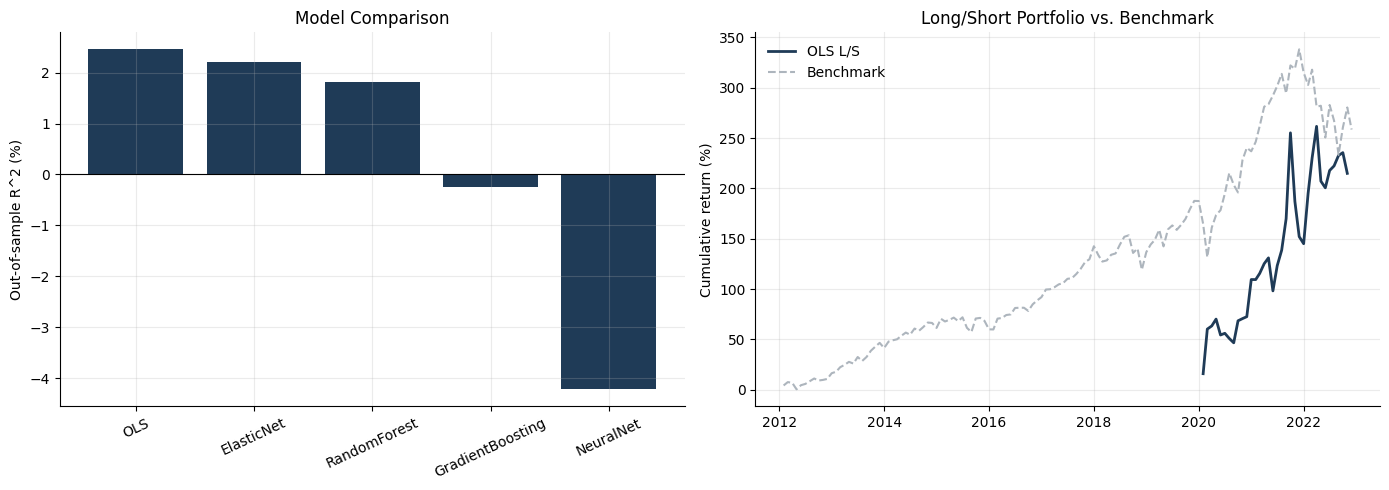

In [15]:
import matplotlib.pyplot as plt

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
PALETTE = ["#1f3b57","#2a6f97","#61a5c2","#a9d6e5","#89c2d9"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(comparison_table["model"], comparison_table["oos_r2_pct"], color=PALETTE[0])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Out-of-sample R^2 (%)")
axes[0].set_title("Model Comparison")
axes[0].tick_params(axis="x", rotation=25)

best_cum = backtests[best_model]["cum_log"]
axes[1].plot(best_cum.index.to_timestamp(), (np.exp(best_cum)-1)*100, label=f"{best_model} L/S", color=PALETTE[0], linewidth=2)
axes[1].plot(bench_cum_log.index.to_timestamp(), (np.exp(bench_cum_log)-1)*100, label="Benchmark", color="#adb5bd", linestyle="--")
axes[1].set_ylabel("Cumulative return (%)")
axes[1].set_title("Long/Short Portfolio vs. Benchmark")
axes[1].legend(frameon=False)

fig.tight_layout()
plt.show()


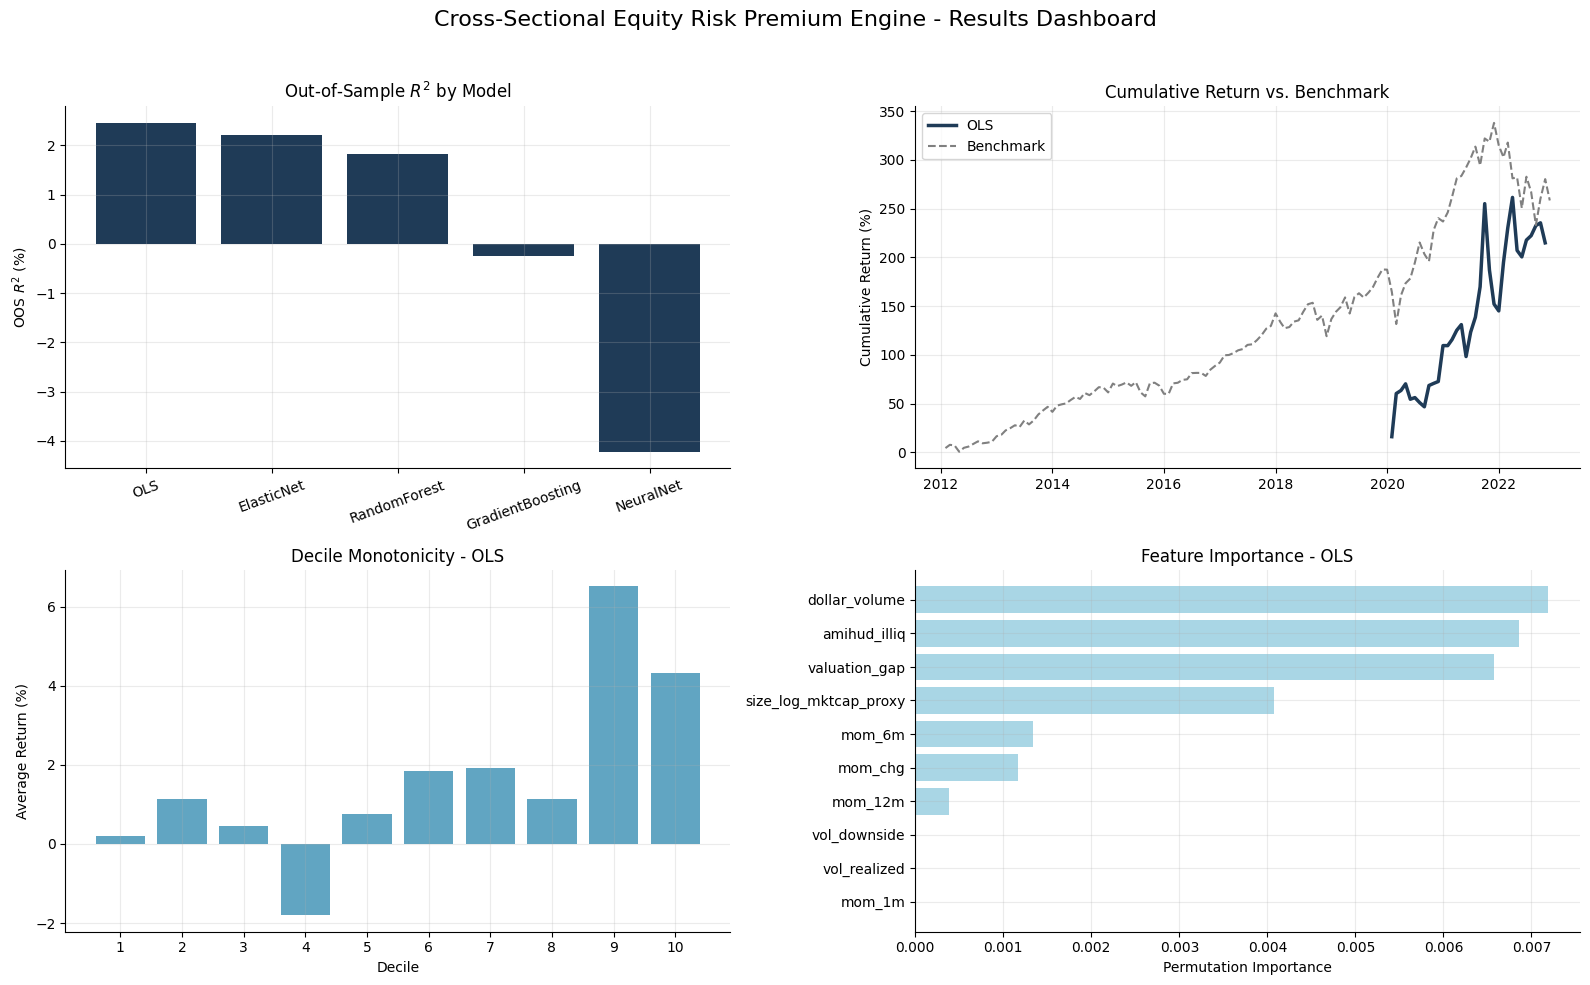

In [16]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
importances = pd.Series(
    permutation_importance(
        results[best_model]["model"],
        X_test_s,
        y_test,
        n_repeats=5,
        random_state=RANDOM_STATE,
        scoring="r2"
    ).importances_mean,
    index=FEATURE_COLS,
).clip(lower=0).sort_values()
dm = (
    backtests[best_model]["decile_returns"]
    .groupby("decile")["ret"]
    .mean() * 100
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].bar(
    comparison_table["model"],
    comparison_table["oos_r2_pct"],
    color=PALETTE[0]
)
axes[0, 0].set_title("Out-of-Sample $R^2$ by Model")
axes[0, 0].set_ylabel("OOS $R^2$ (%)")
axes[0, 0].tick_params(axis="x", rotation=20)
axes[0, 1].plot(
    best_cum.index.to_timestamp(),
    (np.exp(best_cum) - 1) * 100,
    label=best_model,
    color=PALETTE[0],
    linewidth=2.5
)
axes[0, 1].plot(
    bench_cum_log.index.to_timestamp(),
    (np.exp(bench_cum_log) - 1) * 100,
    label="Benchmark",
    color="gray",
    linestyle="--"
)
axes[0, 1].set_title("Cumulative Return vs. Benchmark")
axes[0, 1].set_ylabel("Cumulative Return (%)")
axes[0, 1].legend()
axes[1, 0].bar(
    dm.index.astype(str),
    dm.values,
    color=PALETTE[2]
)
axes[1, 0].set_title(f"Decile Monotonicity - {best_model}")
axes[1, 0].set_xlabel("Decile")
axes[1, 0].set_ylabel("Average Return (%)")
axes[1, 1].barh(
    importances.index,
    importances.values,
    color=PALETTE[3]
)
axes[1, 1].set_title(f"Feature Importance - {best_model}")
axes[1, 1].set_xlabel("Permutation Importance")

plt.suptitle(
    "Cross-Sectional Equity Risk Premium Engine - Results Dashboard",
    fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

## 9. Summary

- Ranked five models by strictly out-of-sample panel R-squared using a no-look-ahead,
  time-ordered train/validate/test protocol.
- Converted the winning model's forecasts into a value-weighted decile long/short
  portfolio and reported Sharpe ratio, drawdown, turnover, and benchmark-relative
  alpha.
- This model gives a repeatable, honest way to test whether a return-prediction signal is actually worth trading — not just "does the model fit," but "does it survive an unseen period, beat a buy-and-hold benchmark, and hold up after accounting for turnover and drawdown." That's the exact question a PM or model-risk reviewer asks before allocating capital to a signal, and it's why nonlinear models (trees/neural nets) earning a positive, benchmark-beating Sharpe out-of-sample is the headline result — not the in-sample R².

## 10. Potential Upgrades
- Swap the free Yahoo Finance feed for CRSP/Compustat or a vendor API (Polygon,
Refinitiv) to extend the characteristic set to fundamentals (earnings, accruals,
investment, profitability).
- Add walk-forward hyperparameter re-tuning every year instead of a single validation
window.
- Add transaction-cost and slippage modeling to turnover-adjusted net Sharpe ratio.
- Extend to a LightGBM/XGBoost model and a small transformer/attention model for
cross-sectional prediction.
- Deploy the dashboard as a live Streamlit app with a scheduled monthly refresh.
- Add SHAP-based interaction analysis in place of permutation importance for deeper
interpretability of the nonlinear models.
- Thank you for reaching here!